# 1. Import the data set you exported in Exercise 4.9 into a new Jupyter notebook. This should be the merged version of your data that contains the new customers column.

In [4]:
# Import libraries
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns
import scipy

In [5]:
# Define the path
path = 'C:\\Users\\User\\Documents\\Career Foundry\\Data Analytics Immersion\\Data Immersion 4. Python Fundamentals for Data Analysts\\Instacart Basket Analysis'

In [6]:
# Import the most up-to-date project data
orders_products_all = pd.read_pickle(os.path.join(path, '02 Data', 'Prepared Data', 'orders_products_all.pkl'))

# 2. Consider any security implications that might exist for this new data. You’ll need to address any PII data in the data before continuing your analysis.

In [8]:
orders_products_all.columns

Index(['user_id', 'first_name', 'surname', 'gender', 'state', 'age',
       'date_joined', 'num_dependants', 'family_status', 'income', 'order_id',
       'order_number', 'orders_day_of_week', 'order_hour_of_day',
       'days_since_prior_order', 'product_id', 'add_to_cart_order',
       'reordered', 'product_name', 'aisle_id', 'department_id', 'prices',
       'price_range_loc', 'busiest_day', 'busiest_days_category',
       'busiest_period_of_day', 'max_order', 'loyalty_flag',
       'avg_price_per_user', 'spending_flag', 'median_days_since_order',
       'order_frequency_flag', '_merge'],
      dtype='object')

In [9]:
# Remove the first_name and surname columns, as the user_id column is already available.
orders_products_all = orders_products_all.drop(columns=['first_name', 'surname'])

# 3. The Instacart officers are interested in comparing customer behavior in different geographic areas. Create a regional segmentation of the data. You’ll need to create a “Region” column based on the “State” column from your customers data set.
## 3a. Use the region information in this Wikipedia article to create your column (you only need to create regions, not divisions).

In [11]:
# Define states for each region
northeast_states = ['Connecticut', 'Maine', 'Massachusetts', 'New Hampshire', 'Rhode Island', 'Vermont', 
                    'New Jersey', 'New York', 'Pennsylvania']
midwest_states = ['Illinois', 'Indiana', 'Iowa', 'Kansas', 'Michigan', 'Minnesota', 'Missouri', 
                  'Nebraska', 'North Dakota', 'Ohio', 'South Dakota', 'Wisconsin']
south_states = ['Alabama', 'Arkansas', 'Delaware', 'Florida', 'Georgia', 'Kentucky', 'Louisiana', 
                'Maryland', 'Mississippi', 'North Carolina', 'Oklahoma', 'South Carolina', 'Tennessee', 
                'Texas', 'Virginia', 'West Virginia', 'District of Columbia']
west_states = ['Alaska', 'Arizona', 'California', 'Colorado', 'Hawaii', 'Idaho', 'Montana', 
               'Nevada', 'New Mexico', 'Oregon', 'Utah', 'Washington', 'Wyoming']

In [12]:
# Define functions for each region
def is_northeast(state):
    return 1 if state in northeast_states else 0

def is_midwest(state):
    return 1 if state in midwest_states else 0

def is_south(state):
    return 1 if state in south_states else 0

def is_west(state):
    return 1 if state in west_states else 0

In [13]:
# Apply the functions
orders_products_all['northeast_flag'] = orders_products_all['state'].apply(is_northeast)
orders_products_all['midwest_flag'] = orders_products_all['state'].apply(is_midwest)
orders_products_all['south_flag'] = orders_products_all['state'].apply(is_south)
orders_products_all['west_flag'] = orders_products_all['state'].apply(is_west)

In [14]:
# Print frequency
print(orders_products_all['northeast_flag'].value_counts())
print(orders_products_all['midwest_flag'].value_counts())
print(orders_products_all['south_flag'].value_counts())
print(orders_products_all['west_flag'].value_counts())

northeast_flag
0    26682123
1     5722736
Name: count, dtype: int64
midwest_flag
0    24807534
1     7597325
Name: count, dtype: int64
south_flag
0    21612974
1    10791885
Name: count, dtype: int64
west_flag
0    24111946
1     8292913
Name: count, dtype: int64


In [75]:
# Cross check to ensure no overlapping flags
overlap = orders_products_all[
    (orders_products_all['northeast_flag'] + 
     orders_products_all['midwest_flag'] + 
     orders_products_all['south_flag'] + 
     orders_products_all['west_flag']) > 1
]
print(overlap)

Empty DataFrame
Columns: [user_id, gender, state, age, date_joined, num_dependants, family_status, income, order_id, order_number, orders_day_of_week, order_hour_of_day, days_since_prior_order, product_id, add_to_cart_order, reordered, product_name, aisle_id, department_id, prices, price_range_loc, busiest_day, busiest_days_category, busiest_period_of_day, max_order, loyalty_flag, avg_price_per_user, spending_flag, median_days_since_order, order_frequency_flag, _merge, northeast_flag, midwest_flag, south_flag, west_flag, region, exclusion_flag, profile, department_name, income_level, purchase_count]
Index: []

[0 rows x 41 columns]


In [16]:
# Combine flags into a Region column
def assign_region(row):
    if row['northeast_flag'] == 1:
        return 'Northeast'
    elif row['midwest_flag'] == 1:
        return 'Midwest'
    elif row['south_flag'] == 1:
        return 'South'
    elif row['west_flag'] == 1:
        return 'West'
    else:
        return 'Unknown'  # Optional, in case any state wasn't assigned correctly

# Apply the function to each row
orders_products_all['Region'] = orders_products_all.apply(assign_region, axis=1)

In [17]:
# Check the frequency of each region
print(orders_products_all['Region'].value_counts())

Region
South        10791885
West          8292913
Midwest       7597325
Northeast     5722736
Name: count, dtype: int64


In [18]:
# Rename the column
orders_products_all.rename(columns={'Region': 'region'}, inplace=True)

In [19]:
# Check the columns
orders_products_all.columns

Index(['user_id', 'gender', 'state', 'age', 'date_joined', 'num_dependants',
       'family_status', 'income', 'order_id', 'order_number',
       'orders_day_of_week', 'order_hour_of_day', 'days_since_prior_order',
       'product_id', 'add_to_cart_order', 'reordered', 'product_name',
       'aisle_id', 'department_id', 'prices', 'price_range_loc', 'busiest_day',
       'busiest_days_category', 'busiest_period_of_day', 'max_order',
       'loyalty_flag', 'avg_price_per_user', 'spending_flag',
       'median_days_since_order', 'order_frequency_flag', '_merge',
       'northeast_flag', 'midwest_flag', 'south_flag', 'west_flag', 'region'],
      dtype='object')

## 3b. Determine whether there’s a difference in spending habits between the different U.S. regions. (Hint: You can do this by crossing the variable you just created with the spending flag.)

In [21]:
# Group Data by Region and Spending Flag
spending_by_region = orders_products_all.groupby(['region', 'spending_flag']).size().unstack(fill_value=0)

In [22]:
# Calculate Percentages
spending_percentages = spending_by_region.div(spending_by_region.sum(axis=1), axis=0) * 100

In [23]:
# Display the Results
print("Spending by Region (Counts):")
print(spending_by_region)

print("\nSpending by Region (Percentages):")
print(spending_percentages)

Spending by Region (Counts):
spending_flag  High spender  Low spender
region                                  
Midwest              155975      7441350
Northeast            108225      5614511
South                209691     10582194
West                 160354      8132559

Spending by Region (Percentages):
spending_flag  High spender  Low spender
region                                  
Midwest            2.053025    97.946975
Northeast          1.891141    98.108859
South              1.943043    98.056957
West               1.933627    98.066373


## The proportions of high and low spenders are very similar across all regions, with less than a 0.2% difference between the highest and lowest percentages of high spenders. This indicates that spending habits are consistent across regions.

# 4. The Instacart CFO isn’t interested in customers who don’t generate much revenue for the app. Create an exclusion flag for low-activity customers (customers with less than 5 orders) and exclude them from the data. Make sure you export this sample.

In [26]:
# Create a function
def create_exclusion_flag(order_count):
    if order_count < 5:
        return 1  # Low-activity customer
    else:
        return 0  # Active customer

In [27]:
# Apply the function
orders_products_all['exclusion_flag'] = orders_products_all['max_order'].apply(create_exclusion_flag)

In [28]:
# Filter out low-activity customers
high_activity_customers = orders_products_all[orders_products_all['exclusion_flag'] == 0]

In [29]:
# Export the filtered dataset to the defined path in one line
high_activity_customers.to_csv(os.path.join(path, '02 Data', 'Prepared Data', 'high_activity_customers.csv'), index=False)

# 5. The marketing and business strategy units at Instacart want to create more-relevant marketing strategies for different products and are, thus, curious about customer profiling in their database. Create a profiling variable based on age, income, certain goods in the “department_id” column, and number of dependents. You might also use the “orders_day_of_week” and “order_hour_of_day” columns if you can think of a way they would impact customer profiles. (Hint: As an example, try thinking of what characteristics would lead you to the profile “Single adult” or “Young parent.”)

# Profile Table
| **Profile**                 | **Age**       | **Dependents**   |
|-----------------------------|---------------|------------------|
| **Single Young**            | 18–39         | 0                |
| **Young Parent**            | 18–39         | >0               |
| **Single Middle-Aged**      | 40–59         | 0                |
| **Middle-Aged with Dependents**| 40–59      | >0               |
| **Single Senior**           | ≥60           | 0                |
| **Senior with Dependents**  | ≥60           | >0               |

In [32]:
# Define conditions for each profile based on age and number of dependents
conditions = [
    # Single Young
    (orders_products_all['age'].between(18, 39)) & 
    (orders_products_all['num_dependants'] == 0),
    
    # Young Parent
    (orders_products_all['age'].between(18, 39)) & 
    (orders_products_all['num_dependants'] > 0),
    
    # Single Middle-Aged
    (orders_products_all['age'].between(40, 59)) & 
    (orders_products_all['num_dependants'] == 0),
    
    # Middle-Aged with Dependents
    (orders_products_all['age'].between(40, 59)) & 
    (orders_products_all['num_dependants'] > 0),
    
    # Single Senior
    (orders_products_all['age'] >= 60) & 
    (orders_products_all['num_dependants'] == 0),
    
    # Senior with Dependents
    (orders_products_all['age'] >= 60) & 
    (orders_products_all['num_dependants'] > 0)
]

# Define corresponding labels for profiles
choices = [
    'Single Young',
    'Young Parent',
    'Single Middle-Aged',
    'Middle-Aged with Dependents',
    'Single Senior',
    'Senior with Dependents'
]

# Create a new profile column
orders_products_all['profile'] = np.select(conditions, choices, default='Other')

# Display profile distribution
print(orders_products_all['profile'].value_counts())

profile
Young Parent                   8382362
Senior with Dependents         8295443
Middle-Aged with Dependents    7629551
Single Young                   2781830
Single Senior                  2771812
Single Middle-Aged             2543861
Name: count, dtype: int64


# Analyze Goods by Profile

In [34]:
# Group by profile and department_id, and count purchases
goods_by_profile = (
    orders_products_all.groupby(['profile', 'department_id'])
    .size()
    .reset_index(name='purchase_count')
)

# Display the grouped data
goods_by_profile.head()

,profile,department_id,purchase_count
0,Middle-Aged with Dependents,1,525676
1,Middle-Aged with Dependents,2,8405
2,Middle-Aged with Dependents,3,275611
3,Middle-Aged with Dependents,4,2225114
4,Middle-Aged with Dependents,5,35099


In [35]:
# Group by profile and sum purchase counts
profile_summary = (
    goods_by_profile.groupby('profile')
    .agg({'purchase_count': 'sum'})
    .reset_index()
)

# Display the profile summary
print(profile_summary)

                       profile  purchase_count
0  Middle-Aged with Dependents         7629551
1       Senior with Dependents         8295443
2           Single Middle-Aged         2543861
3                Single Senior         2771812
4                 Single Young         2781830
5                 Young Parent         8382362


In [36]:
# Define the mapping of department_id to department names
department_mapping = {
    1: 'frozen', 2: 'other', 3: 'bakery', 4: 'produce', 5: 'alcohol', 
    6: 'international', 7: 'beverages', 8: 'pets', 9: 'dry goods pasta', 
    10: 'bulk', 11: 'personal care', 12: 'meat seafood', 13: 'pantry', 
    14: 'breakfast', 15: 'canned goods', 16: 'dairy eggs', 
    17: 'household', 18: 'babies', 19: 'snacks', 20: 'deli', 21: 'missing'
}

In [37]:
# Map department_id to department_name
orders_products_all['department_name'] = orders_products_all['department_id'].map(department_mapping)

In [38]:
# Find the top purchased department for each profile
top_goods_by_profile = goods_by_profile.loc[
    goods_by_profile.groupby('profile')['purchase_count'].idxmax()
]

# Add department names for readability (if mapping exists)
top_goods_by_profile['department_name'] = top_goods_by_profile['department_id'].map(department_mapping)

# Display the top goods by profile
print(top_goods_by_profile[['profile', 'department_name', 'purchase_count']])

                         profile department_name  purchase_count
3    Middle-Aged with Dependents         produce         2225114
24        Senior with Dependents         produce         2427765
45            Single Middle-Aged         produce          746148
66                 Single Senior         produce          812834
87                  Single Young         produce          816463
108                 Young Parent         produce         2450967


In [39]:
# Group by profile and department_id, and count purchases
goods_by_profile = (
    orders_products_all.groupby(['profile', 'department_id'])
    .size()
    .reset_index(name='purchase_count')
)

# Sort by profile and purchase count (descending)
goods_by_profile = goods_by_profile.sort_values(by=['profile', 'purchase_count'], ascending=[True, False])

# Get the top 3 purchased goods for each profile
top_3_goods_by_profile = goods_by_profile.groupby('profile').head(3)

# Map department_id to department names
department_mapping = {
    1: 'frozen', 2: 'other', 3: 'bakery', 4: 'produce', 5: 'alcohol', 
    6: 'international', 7: 'beverages', 8: 'pets', 9: 'dry goods pasta', 
    10: 'bulk', 11: 'personal care', 12: 'meat seafood', 13: 'pantry', 
    14: 'breakfast', 15: 'canned goods', 16: 'dairy eggs', 
    17: 'household', 18: 'babies', 19: 'snacks', 20: 'deli', 21: 'missing'
}

# Add department names for readability
top_3_goods_by_profile['department_name'] = top_3_goods_by_profile['department_id'].map(department_mapping)

# Display the top 3 purchased goods for each profile
print(top_3_goods_by_profile)

                         profile  department_id  purchase_count  \
3    Middle-Aged with Dependents              4         2225114   
15   Middle-Aged with Dependents             16         1267835   
18   Middle-Aged with Dependents             19          678685   
24        Senior with Dependents              4         2427765   
36        Senior with Dependents             16         1376171   
39        Senior with Dependents             19          735524   
45            Single Middle-Aged              4          746148   
57            Single Middle-Aged             16          422752   
60            Single Middle-Aged             19          226489   
66                 Single Senior              4          812834   
78                 Single Senior             16          461911   
81                 Single Senior             19          246796   
87                  Single Young              4          816463   
99                  Single Young             16          46469

C:\Users\User\AppData\Local\Temp\ipykernel_18208\1775058731.py:24: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  top_3_goods_by_profile['department_name'] = top_3_goods_by_profile['department_id'].map(department_mapping)


In [40]:
# Select only the desired columns: profile, purchase_count, and department_name
top_3_goods_by_profile_filtered = top_3_goods_by_profile[['profile', 'purchase_count', 'department_name']]

# Display the filtered DataFrame
print(top_3_goods_by_profile_filtered)

                         profile  purchase_count department_name
3    Middle-Aged with Dependents         2225114         produce
15   Middle-Aged with Dependents         1267835      dairy eggs
18   Middle-Aged with Dependents          678685          snacks
24        Senior with Dependents         2427765         produce
36        Senior with Dependents         1376171      dairy eggs
39        Senior with Dependents          735524          snacks
45            Single Middle-Aged          746148         produce
57            Single Middle-Aged          422752      dairy eggs
60            Single Middle-Aged          226489          snacks
66                 Single Senior          812834         produce
78                 Single Senior          461911      dairy eggs
81                 Single Senior          246796          snacks
87                  Single Young          816463         produce
99                  Single Young          464699      dairy eggs
102                 Singl

# Analyze Income Levels by Profile

In [42]:
# Assign income levels
def assign_income_level(row):
    if row['income'] < 50_000:
        return 'Budget Income'
    elif 50_000 <= row['income'] < 100_000:
        return 'Regular Income'
    elif row['income'] >= 100_000:
        return 'High Income'

# Apply the function to create a new income_level column
orders_products_all['income_level'] = orders_products_all.apply(assign_income_level, axis=1)

# Group by profile and income level, and count occurrences
income_by_profile = (
    orders_products_all.groupby(['profile', 'income_level'])
    .size()
    .reset_index(name='count')
)

# Calculate the percentage of each income level within each profile
income_by_profile['percentage'] = income_by_profile.groupby('profile')['count'].transform(lambda x: (x / x.sum()) * 100)

# Display the results
print(income_by_profile)

                        profile    income_level    count  percentage
0   Middle-Aged with Dependents   Budget Income   673538    8.828016
1   Middle-Aged with Dependents     High Income  5040130   66.060637
2   Middle-Aged with Dependents  Regular Income  1915883   25.111347
3        Senior with Dependents   Budget Income   710843    8.569078
4        Senior with Dependents     High Income  5788003   69.773284
5        Senior with Dependents  Regular Income  1796597   21.657638
6            Single Middle-Aged   Budget Income   224863    8.839437
7            Single Middle-Aged     High Income  1702003   66.906289
8            Single Middle-Aged  Regular Income   616995   24.254273
9                 Single Senior   Budget Income   226682    8.178116
10                Single Senior     High Income  1927910   69.554140
11                Single Senior  Regular Income   617220   22.267744
12                 Single Young   Budget Income   452409   16.263000
13                 Single Young   

# Calculate Profile Percentages

In [44]:
# Calculate the percentage of each profile in the dataset
profile_distribution = (
    orders_products_all['profile'].value_counts(normalize=True) * 100
).reset_index()

# Rename the columns for clarity
profile_distribution.columns = ['profile', 'profile_percentage']

# Display the profile distribution
print(profile_distribution)

                       profile  profile_percentage
0                 Young Parent           25.867608
1       Senior with Dependents           25.599380
2  Middle-Aged with Dependents           23.544466
3                 Single Young            8.584608
4                Single Senior            8.553693
5           Single Middle-Aged            7.850246


# 6. Create an appropriate visualization to show the distribution of profiles

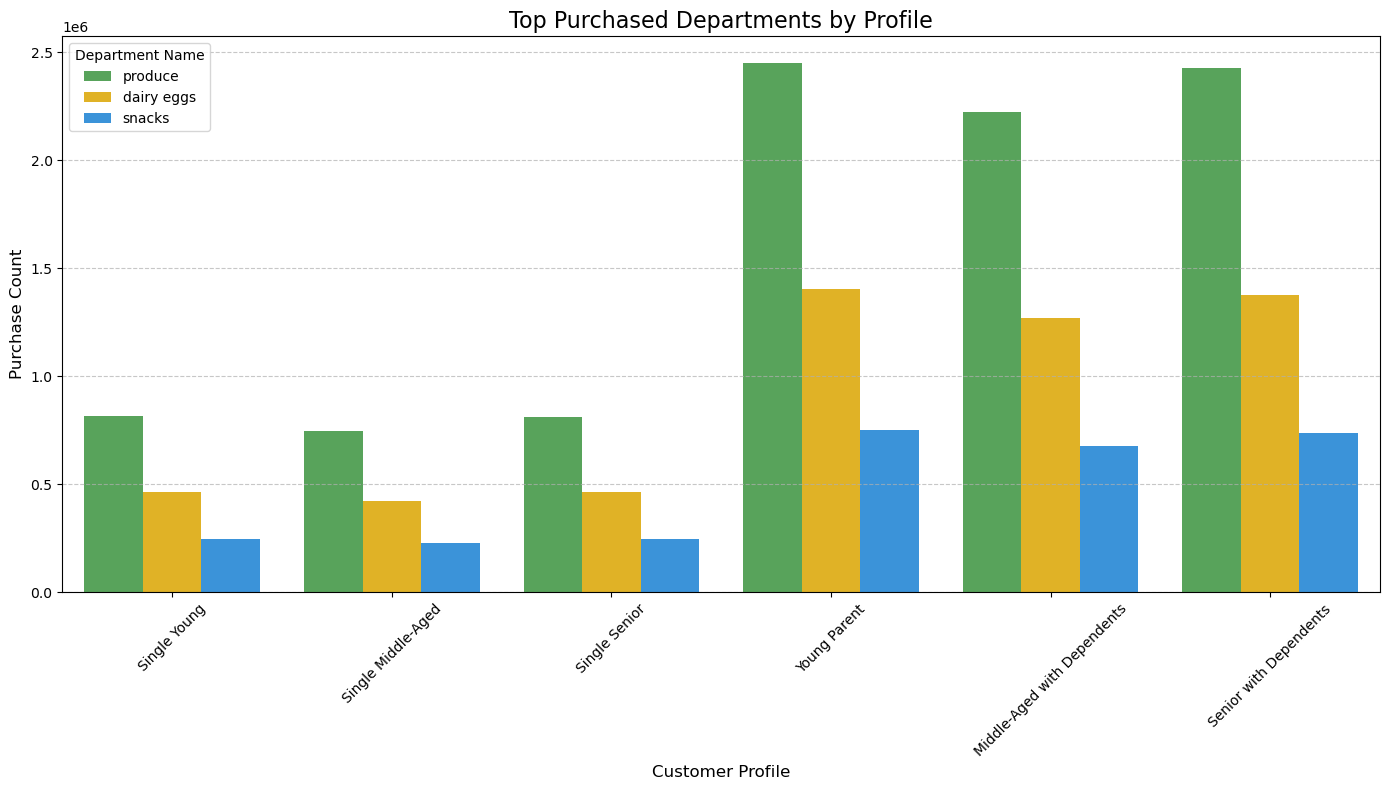

In [46]:
# Data for purchase count by profile and department_name
profile_department_data = {
    "profile": [
        "Single Young", "Single Young", "Single Young",
        "Single Middle-Aged", "Single Middle-Aged", "Single Middle-Aged",
        "Single Senior", "Single Senior", "Single Senior",
        "Young Parent", "Young Parent", "Young Parent",
        "Middle-Aged with Dependents", "Middle-Aged with Dependents", "Middle-Aged with Dependents",
        "Senior with Dependents", "Senior with Dependents", "Senior with Dependents"
    ],
    "department_name": [
        "produce", "dairy eggs", "snacks",
        "produce", "dairy eggs", "snacks",
        "produce", "dairy eggs", "snacks",
        "produce", "dairy eggs", "snacks",
        "produce", "dairy eggs", "snacks",
        "produce", "dairy eggs", "snacks"
    ],
    "purchase_count": [
        816463, 464699, 247513,
        746148, 422752, 226489,
        812834, 461911, 246796,
        2450967, 1405379, 752543,
        2225114, 1267835, 678685,
        2427765, 1376171, 735524
    ],
}

# Convert data to DataFrame
profile_department_df = pd.DataFrame(profile_department_data)

# Define specific colors for each department
department_colors = {
    "produce": "#4caf50",      # Green
    "dairy eggs": "#ffc107",  # Yellow
    "snacks": "#2196f3",      # Blue
}

# Create the visualization
plt.figure(figsize=(14, 8))
sns.barplot(
    x="profile",
    y="purchase_count",
    hue="department_name",
    data=profile_department_df,
    palette=department_colors  # Use the defined color palette
)
plt.title("Top Purchased Departments by Profile", fontsize=16)
plt.xlabel("Customer Profile", fontsize=12)
plt.ylabel("Purchase Count", fontsize=12)
plt.xticks(rotation=45, fontsize=10)
plt.legend(title="Department Name")
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.tight_layout()

# Save the visualization to a file
plt.savefig(os.path.join(path, '04 Analysis', 'Visualizations', 'top_purchased_departments_by_profile.png'), dpi=300, bbox_inches="tight")

# Display the visualization
plt.show()

The visualization shows that "Produce" is the most purchased department across all customer profiles, indicating its universal importance. Young Parents have the highest purchase volumes overall, particularly for "Produce" and "Dairy Eggs," followed by Middle-Aged and Senior customers with dependents. In contrast, Single profiles consistently exhibit lower purchase volumes across all departments, while "Snacks" remain the least purchased category for all profiles. To capitalize on these trends, targeted marketing campaigns should focus on promoting produce and dairy to high-volume profiles like families.

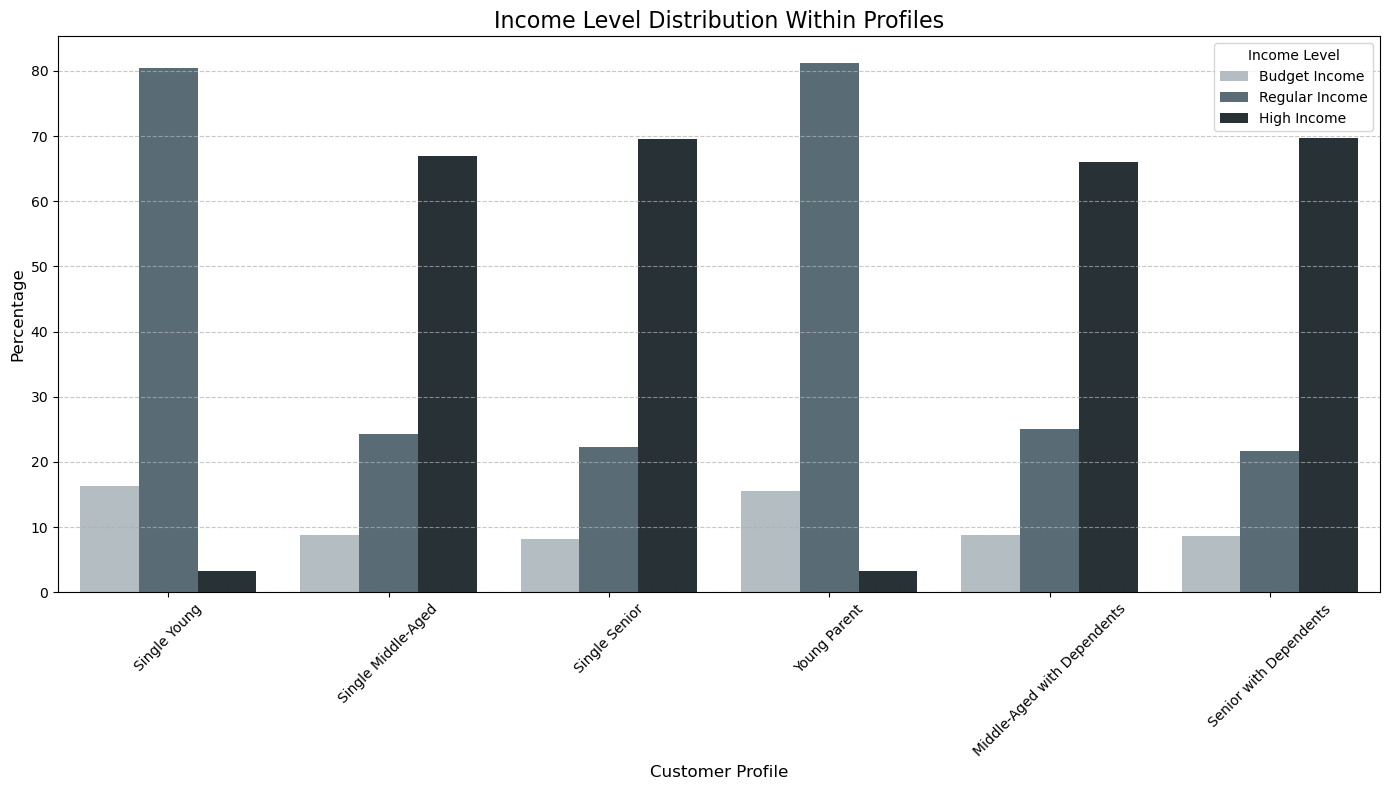

In [48]:
# Define the color palette
income_level_colors = {
    "Budget Income": "#b0bec5",  # Light Gray
    "Regular Income": "#546e7a",  # Medium Gray
    "High Income": "#263238",  # Dark Gray
}

# Data for income distribution within profiles
income_distribution_data = {
    "profile": [
        "Single Young", "Single Young", "Single Young",
        "Single Middle-Aged", "Single Middle-Aged", "Single Middle-Aged",
        "Single Senior", "Single Senior", "Single Senior",
        "Young Parent", "Young Parent", "Young Parent",
        "Middle-Aged with Dependents", "Middle-Aged with Dependents", "Middle-Aged with Dependents",
        "Senior with Dependents", "Senior with Dependents", "Senior with Dependents"
    ],
    "income_level": [
        "Budget Income", "Regular Income", "High Income",
        "Budget Income", "Regular Income", "High Income",
        "Budget Income", "Regular Income", "High Income",
        "Budget Income", "Regular Income", "High Income",
        "Budget Income", "Regular Income", "High Income",
        "Budget Income", "Regular Income", "High Income"
    ],
    "percentage": [
        16.263, 80.496, 3.241,
        8.839, 24.254, 66.906,
        8.178, 22.268, 69.554,
        15.577, 81.243, 3.180,
        8.828, 25.111, 66.061,
        8.569, 21.658, 69.773
    ],
}

# Convert data to DataFrame
income_df = pd.DataFrame(income_distribution_data)

# Visualization: Income Level Distribution Within Profiles
plt.figure(figsize=(14, 8))
sns.barplot(
    x="profile",
    y="percentage",
    hue="income_level",
    data=income_df,
    palette=income_level_colors  # Apply custom color palette
)
plt.title("Income Level Distribution Within Profiles", fontsize=16)
plt.xlabel("Customer Profile", fontsize=12)
plt.ylabel("Percentage", fontsize=12)
plt.xticks(rotation=45, fontsize=10)
plt.legend(title="Income Level")
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.tight_layout()

# Save the visualization to a file
plt.savefig(os.path.join(path, '04 Analysis', 'Visualizations', 'income_level_distribution_within_profiles.png'), dpi=300, bbox_inches="tight")

# Display the visualization
plt.show()

The visualization reveals distinct income patterns across customer profiles. Younger profiles, including "Single Young" and "Young Parent," are predominantly composed of individuals with Regular Income, accounting for over 80% in both groups. In contrast, middle-aged and senior profiles, such as "Single Middle-Aged" (66.9% High Income) and "Single Senior" (69.6% High Income), are largely dominated by high-income individuals. This may suggest that older, wealthier customers are more likely to be tech-savvy and utilize Instacart's online services, while younger customers, even with lower incomes, still represent significant users of the platform. Budget Income remains a smaller share across all profiles, with its highest presence in younger groups.

# 7. Aggregate the max, mean, and min variables on a customer-profile level for usage frequency and expenditure.

In [51]:
# Aggregate max, mean, and min for `max_order` (usage frequency) and `avg_price_per_user` (expenditure) by profile
aggregated_data = orders_products_all.groupby('profile').agg({
    'max_order': ['max', 'mean', 'min'],  # Usage frequency
    'avg_price_per_user': ['max', 'mean', 'min']  # Expenditure
}).reset_index()

# Rename columns for better readability
aggregated_data.columns = ['Profile', 
                           'Max Usage Frequency', 'Mean Usage Frequency', 'Min Usage Frequency',
                           'Max Expenditure', 'Mean Expenditure', 'Min Expenditure']

# Display the aggregated data
print(aggregated_data)

# Save the aggregated data to a CSV file
aggregated_data.to_csv(os.path.join(path, '02 Data', 'Prepared Data', 'aggregated_customer_profiles.csv'), index=False)

                       Profile  Max Usage Frequency  Mean Usage Frequency  \
0  Middle-Aged with Dependents                   99             32.847849   
1       Senior with Dependents                   99             32.881573   
2           Single Middle-Aged                   99             33.672607   
3                Single Senior                   99             33.287212   
4                 Single Young                   99             32.969530   
5                 Young Parent                   99             33.168374   

   Min Usage Frequency  Max Expenditure  Mean Expenditure  Min Expenditure  
0                    3     11772.100000         11.781497              1.1  
1                    1      8703.400000         11.866805              1.0  
2                    3     25005.425000         13.154380              1.0  
3                    2     14042.512281         11.453674              1.2  
4                    3      8794.882427         11.864935              1.0 

# 8. Compare your customer profiles with regions and departments. Can you identify a link between them? Customers may demonstrate different behaviors across regions, which could make this information important.

In [53]:
# Aggregate purchase counts by profile, region, and department_name
region_department_data = (
    orders_products_all.groupby(['profile', 'region', 'department_name'])
    .size()
    .reset_index(name='purchase_count')
)
# Pivot the data for better visualization
pivot_table = region_department_data.pivot_table(
    index=['profile', 'region'], 
    columns='department_name', 
    values='purchase_count', 
    aggfunc='sum'
).fillna(0)

# Display the pivot table
print(pivot_table)

department_name                        alcohol  babies  bakery  beverages  \
profile                     region                                          
Middle-Aged with Dependents Midwest       7698   23037   66165     149195   
                            Northeast     6221   17623   49303     118546   
                            South        10917   34369   88965     208435   
                            West         10263   25873   71178     162384   
Senior with Dependents      Midwest       8736   24241   69122     160859   
                            Northeast     5956   18874   54153     124380   
                            South        13776   37184   99523     232014   
                            West          9581   27287   76821     175430   
Single Middle-Aged          Midwest       3402    7868   22489      50566   
                            Northeast     2764    6374   15429      36693   
                            South         3919   11536   30300      70731   

Across all profiles and regions, "Produce" consistently ranks as the most purchased department, reflecting universal demand. The South demonstrates higher purchase counts across most departments, which may be influenced by its larger population, resulting in a greater number of potential Instacart users. However, regional shopping habits and customer engagement with online grocery shopping likely also play a role. Department preferences differ slightly across regions; for instance, "Snacks" and "Pantry" purchases are slightly more prominent in the South and Midwest, while "Babies" products see relatively higher activity in the Northeast.

# 9. Produce suitable charts to illustrate your results and export them in your project folder.

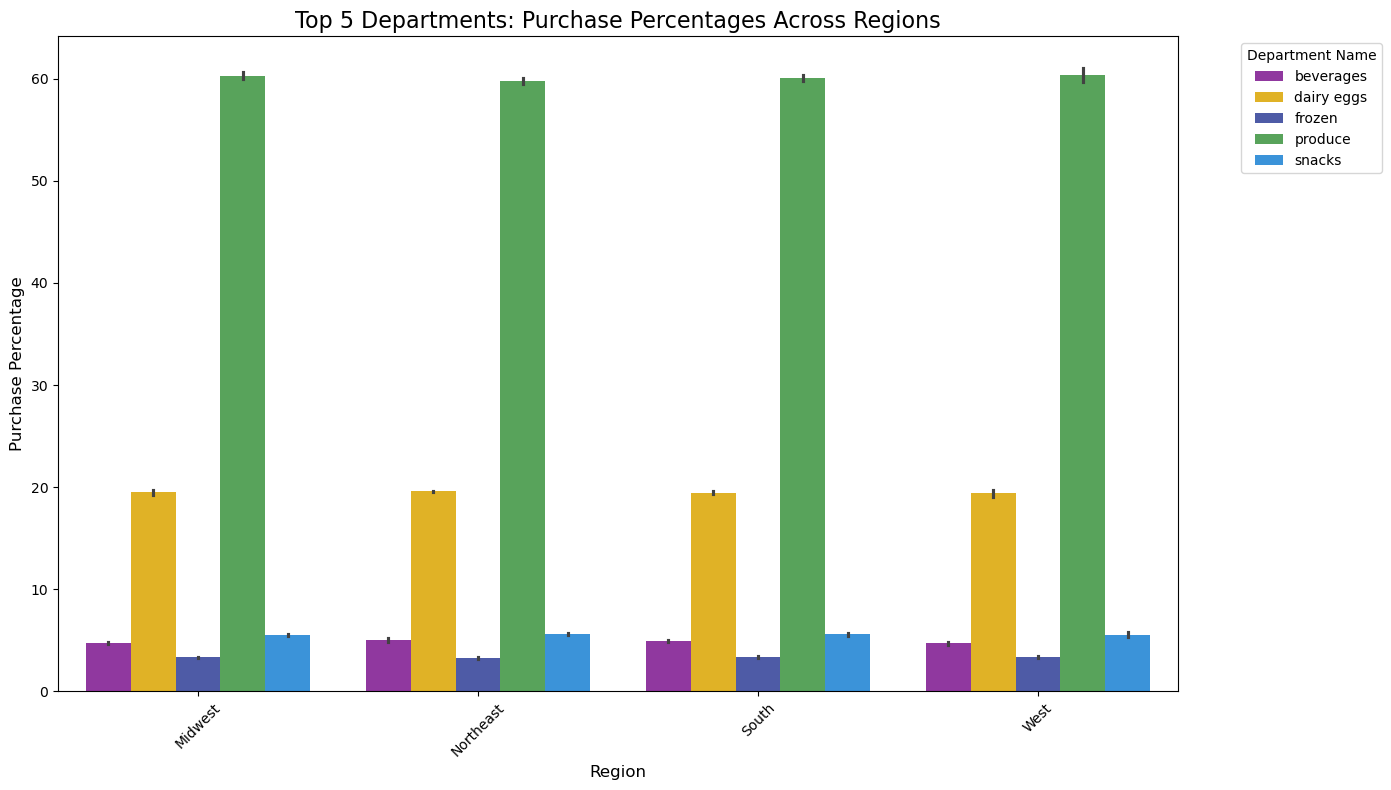

In [65]:
# Add a column to count purchases if not already present in the dataset
orders_products_all['purchase_count'] = orders_products_all.groupby(
    ['region', 'profile', 'department_name']
)['order_id'].transform('count')  # Counting the number of purchases based on 'order_id'

# Group the data by region, profile, and department to calculate total purchase counts
region_department_data = orders_products_all.groupby(
    ['region', 'profile', 'department_name']
)['purchase_count'].sum().reset_index()

# Calculate the percentage of purchases within each profile and region
region_department_percentage = region_department_data.copy()
region_department_percentage['purchase_percentage'] = (
    region_department_percentage.groupby(['region', 'profile'])['purchase_count']
    .transform(lambda x: 100 * x / x.sum())  # Normalize purchases to percentages
)

# Identify the top 5 departments by total purchase percentages
top_departments = (
    region_department_percentage.groupby("department_name")["purchase_percentage"]
    .sum()
    .sort_values(ascending=False)
    .head(5)
    .index.tolist()
)

# Filter data to include only the top 5 departments
top_departments_data = region_department_percentage[
    region_department_percentage["department_name"].isin(top_departments)
]

# Define colors for consistent visualization of the top departments
department_colors = {
    "produce": "#4caf50",      # Green
    "dairy eggs": "#ffc107",  # Yellow
    "snacks": "#2196f3",      # Blue
    "beverages": "#9c27b0",   # Purple
    "frozen": "#3f51b5"       # Dark Blue
}

# Create a bar plot to visualize the purchase percentages of the top 5 departments by region
plt.figure(figsize=(14, 8))
sns.barplot(
    x="region",
    y="purchase_percentage",
    hue="department_name",
    data=top_departments_data,
    palette=department_colors  # Use the defined color palette
)
plt.title("Top 5 Departments: Purchase Percentages Across Regions", fontsize=16)
plt.xlabel("Region", fontsize=12)
plt.ylabel("Purchase Percentage", fontsize=12)
plt.xticks(rotation=45, fontsize=10)  # Rotate region labels for better readability
plt.legend(title="Department Name", bbox_to_anchor=(1.05, 1), loc="upper left")  # Position legend outside the plot
plt.tight_layout()

# Save the plot to the appropriate folder
plt.savefig(
    os.path.join(path, '04 Analysis', 'Visualizations', 'top_5_departments.png'),
    dpi=300,
    bbox_inches="tight"
)

# Display the plot
plt.show()

# To fill up the final report

In [69]:
# Display the list of columns in the DataFrame
print(orders_products_all.columns)

Index(['user_id', 'gender', 'state', 'age', 'date_joined', 'num_dependants',
       'family_status', 'income', 'order_id', 'order_number',
       'orders_day_of_week', 'order_hour_of_day', 'days_since_prior_order',
       'product_id', 'add_to_cart_order', 'reordered', 'product_name',
       'aisle_id', 'department_id', 'prices', 'price_range_loc', 'busiest_day',
       'busiest_days_category', 'busiest_period_of_day', 'max_order',
       'loyalty_flag', 'avg_price_per_user', 'spending_flag',
       'median_days_since_order', 'order_frequency_flag', '_merge',
       'northeast_flag', 'midwest_flag', 'south_flag', 'west_flag', 'region',
       'exclusion_flag', 'profile', 'department_name', 'income_level',
       'purchase_count'],
      dtype='object')


In [71]:
observations_to_remove = orders_products_all[orders_products_all['exclusion_flag'] == 1].shape[0]
print(observations_to_remove)

1440295


In [73]:
final_count = orders_products_all[orders_products_all['exclusion_flag'] == 0].shape[0]
print(final_count)

30964564
